## Imports

In [1]:
# Data handling & Fiture extracting
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
import tldextract

# Model training & evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
#from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#%pip install tldextract

## Data Handaling

In [3]:
df = pd.read_csv("malicious_phish.csv")
df.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


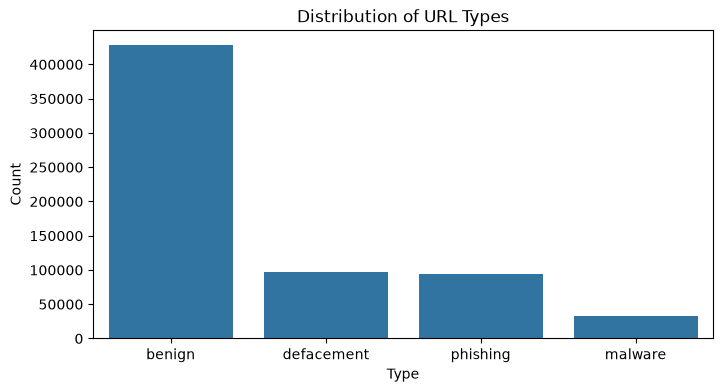

In [4]:
plt.figure(figsize=(8, 4))
sns.countplot(x="type", data=df, order=df["type"].value_counts().index)
plt.title("Distribution of URL Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [5]:
df.isna().sum()

url     0
type    0
dtype: int64

## Feature Extracting

### 1.Encode Type

In [6]:
from sklearn.preprocessing import LabelEncoder

encode = LabelEncoder()
df["type_code"]=encode.fit_transform(df['type'])
df.head()

,url,type,type_code
0,br-icloud.com.br,phishing,3
1,mp3raid.com/music/krizz_kaliko.html,benign,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1


### 2.URL Length

In [7]:
df["url_len"]=df["url"].apply(lambda x: len(str(x)))
df.head()

,url,type,type_code,url_len
0,br-icloud.com.br,phishing,3,16
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235


### 3.Check IP

Feature: IP Address Detection (use_of_ip)
Purpose: Legitimate websites use domain names (e.g., google.com), whereas attackers often use raw IP addresses (e.g., [http://192.168.1.1/login](http://192.168.1.1/login)) to bypass DNS domain blacklists and host temporary phishing pages.

Extraction: Regular expressions scan each URL to detect IPv4, IPv6, or hexadecimal IP formats in the hostname.

Encoding: A binary feature where:

1 = IP address detected (suspicious)

0 = Standard domain name used (normal)

In [8]:
def having_ip_address(url):
    match = re.search(
        r"(([01]?\d\d?|2[0-4]\d|25[0-5])\.([01]?\d\d?|2[0-4]\d|25[0-5])\.([01]?\d\d?|2[0-4]\d|25[0-5])\."
        r"([01]?\d\d?|2[0-4]\d|25[0-5]))(?:\/|:|$)|"  # IPv4
        r"((0x[0-9a-fA-F]{1,2})\.(0x[0-9a-fA-F]{1,2})\.(0x[0-9a-fA-F]{1,2})\.(0x[0-9a-fA-F]{1,2}))(?:\/|:|$)|"  # IPv4 hex
        r"(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}",  # IPv6
        str(url),
                  )  
    if match:
        return 1
    else:
        return 0
df['check_IP'] = df['url'].apply(lambda i: having_ip_address(i))
df.head()

,url,type,type_code,url_len,check_IP
0,br-icloud.com.br,phishing,3,16,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0


In [9]:
df["check_IP"].value_counts()

check_IP
0    638966
1     12225
Name: count, dtype: int64

In [10]:
df[df["type"] == "benign"]["check_IP"].value_counts()

check_IP
0    428008
1        95
Name: count, dtype: int64

### 4.URL Depth

In [11]:
def get_depth(url):
    # Parse URL path and split by '/'
    path_segments = [segment for segment in urlparse(str(url)).path.split("/") if segment]
    return len(path_segments)

df["url_depth"] = df["url"].apply(get_depth)
df.head()

,url,type,type_code,url_len,check_IP,url_depth
0,br-icloud.com.br,phishing,3,16,0,1
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,3
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,4
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,0,1
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1


### 5.Hostname Length

In [12]:
def get_hostname_length(url):
    ext = tldextract.extract(str(url))
    return len(ext.fqdn)

df["hostname_len"] = df["url"].apply(get_hostname_length)
df.head()

,url,type,type_code,url_len,check_IP,url_depth,hostname_len
0,br-icloud.com.br,phishing,3,16,0,1,16
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,3,11
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,4,14
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,0,1,21
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1,23


### 6.Count Suspicious Word URL

In [13]:
def suspicious_words(url):
    match = re.search(
        r"secure|account|update|banking|login|signin|verify|verification|confirm|admin|service|ebayisapi|webscr|password|credential|paypal|support",
        str(url),
        flags=re.IGNORECASE,
    )
    if match:
        return 1
    else:
        return 0


df["sus_url"] = df["url"].apply(lambda i: suspicious_words(i))
df.head()

,url,type,type_code,url_len,check_IP,url_depth,hostname_len,sus_url
0,br-icloud.com.br,phishing,3,16,0,1,16,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,3,11,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,4,14,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,0,1,21,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1,23,0


In [14]:
df["sus_url"].value_counts()

sus_url
0    606053
1     45138
Name: count, dtype: int64

### 7.Count @

In [15]:
def count_at(url):
    return str(url).count("@")
df["count_at"] = df["url"].apply(count_at)
df.head()

,url,type,type_code,url_len,check_IP,url_depth,hostname_len,sus_url,count_at
0,br-icloud.com.br,phishing,3,16,0,1,16,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,3,11,0,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,4,14,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,0,1,21,0,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1,23,0,0


In [16]:
df["count_at"].value_counts()

count_at
0     649845
1       1290
2         40
3          9
4          3
10         3
6          1
Name: count, dtype: int64

### 8.Count Shortening URL

In [17]:
def shortening_service(url):
    match = re.search(
        r"bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|"
        r"yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|"
        r"short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|"
        r"doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|"
        r"db\.tt|qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|"
        r"q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|"
        r"x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|"
        r"tr\.im|link\.zip\.net",
        str(url),
        flags=re.IGNORECASE,
    )
    if match:
        return 1
    else:
        return 0


df["short_url"] = df["url"].apply(lambda i: shortening_service(i))
df.head()

,url,type,type_code,url_len,check_IP,url_depth,hostname_len,sus_url,count_at,short_url
0,br-icloud.com.br,phishing,3,16,0,1,16,0,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,3,11,0,0,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,4,14,0,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,0,1,21,0,0,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1,23,0,0,0


In [18]:
df["short_url"].value_counts()

short_url
0    611434
1     39757
Name: count, dtype: int64

## 9.Convert type_code: 0 remains 0 (benign), while 1, 2, and 3 become 1 (malicious)

In [19]:
df["binary_type"] = (df["type_code"] != 0).astype(int)

print(df["binary_type"].value_counts())
df.head()

binary_type
0    428103
1    223088
Name: count, dtype: int64


,url,type,type_code,url_len,check_IP,url_depth,hostname_len,sus_url,count_at,short_url,binary_type
0,br-icloud.com.br,phishing,3,16,0,1,16,0,0,0,1
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,3,11,0,0,0,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,4,14,0,0,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,0,1,21,0,0,0,1
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1,23,0,0,0,1


## 10.Count special characters frequently 

In [20]:
df["count_dot"] = df["url"].apply(lambda i: str(i).count("."))
df["count_hyphen"] = df["url"].apply(lambda i: str(i).count("-"))
df["count_slash"] = df["url"].apply(lambda i: str(i).count("/"))
df["count_question"] = df["url"].apply(lambda i: str(i).count("?"))
df["count_equal"] = df["url"].apply(lambda i: str(i).count("="))
df["count_percent"] = df["url"].apply(lambda i: str(i).count("%"))
df.head()

,url,type,type_code,url_len,check_IP,url_depth,hostname_len,sus_url,count_at,short_url,binary_type,count_dot,count_hyphen,count_slash,count_question,count_equal,count_percent
0,br-icloud.com.br,phishing,3,16,0,1,16,0,0,0,1,2,1,0,0,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,3,11,0,0,0,0,2,0,2,0,0,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,4,14,0,0,0,0,2,0,3,0,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,0,1,21,0,0,0,1,3,1,3,1,4,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1,23,0,0,0,1,2,1,3,1,3,0


## 11.Count digits and compute digit ratio

In [21]:

def digit_count(url):
    return sum(c.isdigit() for c in str(url))


df["count_digits"] = df["url"].apply(digit_count)
df["digit_ratio"] = df["count_digits"] / df["url_len"].replace(0, 1)
df.head()

,url,type,type_code,url_len,check_IP,url_depth,hostname_len,sus_url,count_at,short_url,binary_type,count_dot,count_hyphen,count_slash,count_question,count_equal,count_percent,count_digits,digit_ratio
0,br-icloud.com.br,phishing,3,16,0,1,16,0,0,0,1,2,1,0,0,0,0,0,0.000000
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,3,11,0,0,0,0,2,0,2,0,0,0,1,0.028571
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,4,14,0,0,0,0,2,0,3,0,0,0,1,0.032258
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,0,1,21,0,0,0,1,3,1,3,1,4,0,7,0.079545
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1,23,0,0,0,1,2,1,3,1,3,0,22,0.093617


## Training & Evaluation

### 1.Split the data (80% for training  & 20% for testing)

In [22]:
X = df.drop(columns=["url", "type", "type_code", "binary_type"], errors="ignore")
y = df["binary_type"]

print(f"Features used for training:{ list(X.columns)}\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

Features used for training:['url_len', 'check_IP', 'url_depth', 'hostname_len', 'sus_url', 'count_at', 'short_url', 'count_dot', 'count_hyphen', 'count_slash', 'count_question', 'count_equal', 'count_percent', 'count_digits', 'digit_ratio']



### 2.Train the model using RandomForestClassifier

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

print("Training RandomForestClassifier...")
rf_model.fit(X_train, y_train)
print("Training complete!\n")


Training RandomForestClassifier...
Training complete!



### 3.Evaluation using Confusion Matrix

In [24]:
y_pred = rf_model.predict(X_test)
class_labels = ["Benign", "Malicious"]

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print(
    "Classification Report:\n",
    classification_report(y_test, y_pred, target_names=class_labels),
)

Accuracy Score: 0.9582

Classification Report:
               precision    recall  f1-score   support

      Benign       0.98      0.96      0.97     85621
   Malicious       0.93      0.95      0.94     44618

    accuracy                           0.96    130239
   macro avg       0.95      0.96      0.95    130239
weighted avg       0.96      0.96      0.96    130239



### 4.Plot 2x2 Confusion Matrix

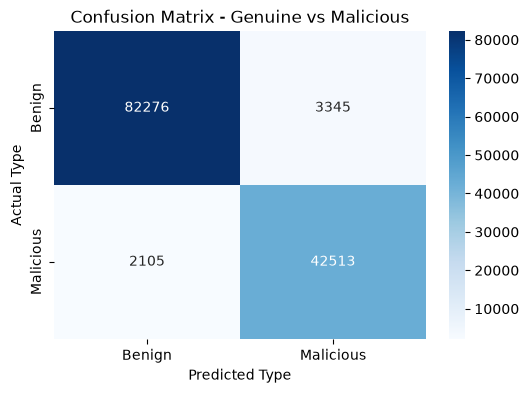

In [25]:

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
)
plt.title("Confusion Matrix - Genuine vs Malicious")
plt.xlabel("Predicted Type")
plt.ylabel("Actual Type")
plt.show()


### 5.Feature Importance Plot

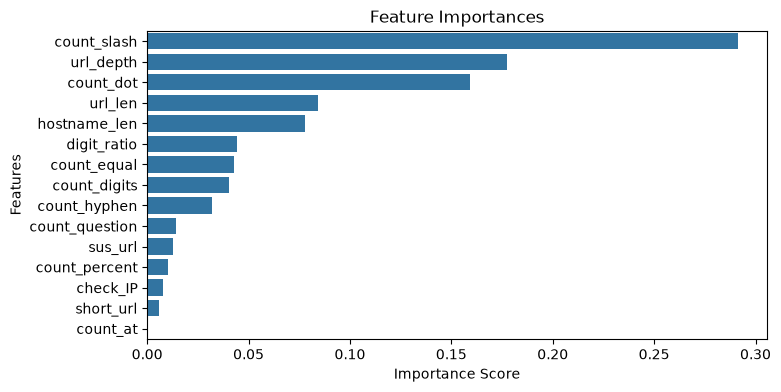

In [26]:
feature_importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


### 6.Checking underfitting and overfitting

In [27]:
# 1. Standard accuracy score using model.score()
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)

print(f"Training Accuracy (Score): {train_score:.4f}")
print(f"Testing Accuracy (Score):  {test_score:.4f}")

Training Accuracy (Score): 0.9688
Testing Accuracy (Score):  0.9582


## Import Model

In [28]:
import pickle

In [29]:
pickle.dump(rf_model,open('URL_Detection.pkl','wb'))

In [31]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
import tldextract
import pickle

def extract_features(url: str) -> pd.DataFrame:
    url_str = str(url)
    
    # 1. url_len
    url_len = len(url_str)
    
    # 2. check_IP
    ip_match = re.search(
        r"(([01]?\d\d?|2[0-4]\d|25[0-5])\.([01]?\d\d?|2[0-4]\d|25[0-5])\.([01]?\d\d?|2[0-4]\d|25[0-5])\."
        r"([01]?\d\d?|2[0-4]\d|25[0-5]))(?:\/|:|$)|"
        r"((0x[0-9a-fA-F]{1,2})\.(0x[0-9a-fA-F]{1,2})\.(0x[0-9a-fA-F]{1,2})\.(0x[0-9a-fA-F]{1,2}))(?:\/|:|$)|"
        r"(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}",
        url_str
    )
    check_IP = 1 if ip_match else 0
    
    # 3. url_depth
    path_segments = [s for s in urlparse(url_str).path.split("/") if s]
    url_depth = len(path_segments)
    
    # 4. hostname_len
    ext = tldextract.extract(url_str)
    hostname_len = len(ext.fqdn)
    
    # 5. sus_url
    sus_match = re.search(
        r"secure|account|update|banking|login|signin|verify|verification|confirm|admin|service|ebayisapi|webscr|password|credential|paypal|support",
        url_str,
        flags=re.IGNORECASE
    )
    sus_url = 1 if sus_match else 0
    
    # 6. count_at
    count_at = url_str.count("@")
    
    # 7. short_url
    short_match = re.search(
        r"bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|"
        r"yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|"
        r"short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|"
        r"doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|"
        r"db\.tt|qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|"
        r"q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|"
        r"x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|"
        r"tr\.im|link\.zip\.net",
        url_str,
        flags=re.IGNORECASE
    )
    short_url = 1 if short_match else 0
    
    # 8-13. special character counts
    count_dot = url_str.count(".")
    count_hyphen = url_str.count("-")
    count_slash = url_str.count("/")
    count_question = url_str.count("?")
    count_equal = url_str.count("=")
    count_percent = url_str.count("%")
    
    # 14-15. digit metrics
    count_digits = sum(c.isdigit() for c in url_str)
    digit_ratio = count_digits / (url_len if url_len != 0 else 1)
    
    # Match the exact column names and order from training
    features = {
        'url_len': [url_len],
        'check_IP': [check_IP],
        'url_depth': [url_depth],
        'hostname_len': [hostname_len],
        'sus_url': [sus_url],
        'count_at': [count_at],
        'short_url': [short_url],
        'count_dot': [count_dot],
        'count_hyphen': [count_hyphen],
        'count_slash': [count_slash],
        'count_question': [count_question],
        'count_equal': [count_equal],
        'count_percent': [count_percent],
        'count_digits': [count_digits],
        'digit_ratio': [digit_ratio]
    }
    
    return pd.DataFrame(features)

In [48]:

with open('URL_Detection.pkl', 'rb') as f:
    model = pickle.load(f)
# eextract_features
test_url = "(https://www.youtube.com)"
input_features = extract_features(test_url)

# Predict
pred = model.predict(input_features)[0]
label = "Malicious" if pred == 1 else "Benign"

print(f"URL: {test_url}")
print(f"Result: {label}")

URL: (https://www.youtube.com)
Result: Benign
